# Technische Universität Clausthal - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Technische Universität Clausthal' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qb8nc58' -- 'Technische Universität Clausthal'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Clausthal,"Thermal Process Technology, TU Clausthal (CUTE...",https://openalex.org/W4311938034
1,not assigned,Technische Universität Clausthal,Institute of Polymer Materials and Plastics En...,https://openalex.org/W4206450853
2,not assigned,Technische Universität Clausthal,"Institute of Applied Mechanics, Clausthal Univ...",https://openalex.org/W4206450853
3,not assigned,Technische Universität Clausthal,"Clausthal University of Technology,Institute o...",https://openalex.org/W4312198830
4,not assigned,Technische Universität Clausthal,"Institute of Management and Economics, Clausth...",https://openalex.org/W4312198830


In [127]:
MAPPING_DICT = {
    'Clausthaler Umwelttechnik Forschungszentrum (CUTEC)': ['cutec'],
    'Clausthaler Zentrum für Materialtechnik (CZM)': ['(czm)', 'cent(er|re) (for|of) material(s)? technology', 'zentrum für materialtech(nik|nologie)',
                                                     ],
    'Fakultät für Energie- und Wirtschaftswissenschaften': ['mineral', 'geo(-engineering|mechanic)', 'market', 'fuel technology',
                                                            '(sub)?surface energy', 'power engineering', 'geolog(ie|y)', 'economics',
                                                            'thermodynamic', '(?<!elektrochemische\s)verfahrenstechnik', 'betriebswirtschaftslehre',
                                                            'mining', 'geophysi(k|cs)', '(energie|deponie)technik', 'petroleum', 'faculty for energy',
                                                            'economics', 'endlagerforschung', '(geotechnical|energy|electrical) engineering',
                                                            'kreislaufwirtschaftssysteme', 'repository', 'electric(al)? power',
                                                            'circular economy', 'digital transformation', 'disposal', 'socio-technical'
                                                           ], 
    'Fakultät für Mathematik/Informatik und Maschinenbau': ['software (and system|systems engineering)', 'tribology', 
                                                            'chemical', 'mathemati(cs|k|cal)', 'elektrochemisch',
                                                            'informati(k|cs)', 'particle', 'metrology',
                                                            'welding', 'stochastics', 'anlagentechnik',
                                                            'computer science', '(applied|technical) mechanics',
                                                            'data science', 'continuous optimization', 'scientific computing',
                                                            'maschinenwesen', 'informationstech(-)?nik',
                                                            '(hcis)', 'separation', 'human(-|\s)centered', 
                                                            'electrical information', '(mechanical|plant) engineering',
                                                            '(schweiß|mess|regelungs)technik', 'mechanical', 'isse,', 'isaf,'
                                                           ],
    'Fakultät für Natur- und Materialwissenschaften': ['materials (science|engineering)', 'chemi(e|stry)', 'non(‐|-)?metallic', 
                                                       'metallurg(ie|y)', 'physical technologies', 'nichtmetallische',
                                                       'theoreti(sche|cal) physi(k|cs)', 'werkstoff(kunde|technik)',
                                                       'polymer', 'energieforschung', 'energy research cent(er|re)',
                                                       'forschungsbrauerei'
                                                      ],
    'Forschungszentrum Energiespeichertechnologien': ['energy storage', 'energiespeichertechnologien'],
    #'Geomuseum': [],
    #'LaserAnwendungsCentrum': [],
    'Simulationswissenschaftliches Zentrum Clausthal-Göttingen': ['simulation science center'], #selbst ergänzt
}

In [128]:
with open('./mapping_tables_fak/clausthal.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [129]:
df_with_inst = oal.copy()

In [130]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [131]:
df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [132]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Clausthaler Umwelttechnik Forschungszentrum (C...,Technische Universität Clausthal,"Thermal Process Technology, TU Clausthal (CUTE...",https://openalex.org/W4311938034
1,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institute of Polymer Materials and Plastics En...,https://openalex.org/W4206450853
2,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,"Institute of Applied Mechanics, Clausthal Univ...",https://openalex.org/W4206450853
3,Fakultät für Energie- und Wirtschaftswissensch...,Technische Universität Clausthal,"Clausthal University of Technology,Institute o...",https://openalex.org/W4312198830
4,Fakultät für Energie- und Wirtschaftswissensch...,Technische Universität Clausthal,"Institute of Management and Economics, Clausth...",https://openalex.org/W4312198830
...,...,...,...,...
3565,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3215011279
3566,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3022257217
3567,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W2979565550
3568,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3111522935


In [133]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['TU Clausthal, Erzstraße\xa020, 38678, Clausthal-Zellerfeld, Deutschland',
       'Technical University Clausthal, Clausthal-Zellerfeld, Germany',
       'Technische Universitat Clausthal',
       'TU Clausthal, Julius-Albert Straße 4, 38178, Clausthal, Germany',
       'Clausthal Executive School, Clausthal University of Technology, Albrecht-von-Groddeck-Str. 7, 38678, Clausthal-Zellerfeld, Germany',
       'Clausthal University of Technology, 38678, Clausthal-Zellerfeld, Germany',
       'IEPT, Clausthal University of Technology, Am Stollen 19A, 38678 Clausthal-Zellerfeld, Germany',
       'Clausthal University of Technology,Clausthal-Zellerfeld,Germany',
       'Technical University of Clausthal, 38678 Clausthal-Zellefeld, Germany',
       'Clausthal University of Technology , Celle, Germany',
       'Clausthal University of Technology , Clausthal-Zellerfeld, Germany',
       'TU Clausthal, Clausthal-Zellerfeld, Germany',
       'Clausthal University of Technology; University

In [134]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Clausthaler Umwelttechnik Forschungszentrum (C...,37
1,Clausthaler Zentrum für Materialtechnik (CZM),127
2,Fakultät für Energie- und Wirtschaftswissensch...,693
3,Fakultät für Mathematik/Informatik und Maschin...,961
4,Fakultät für Natur- und Materialwissenschaften,894
5,Forschungszentrum Energiespeichertechnologien,310
6,Simulationswissenschaftliches Zentrum Claustha...,11
7,NaN,537


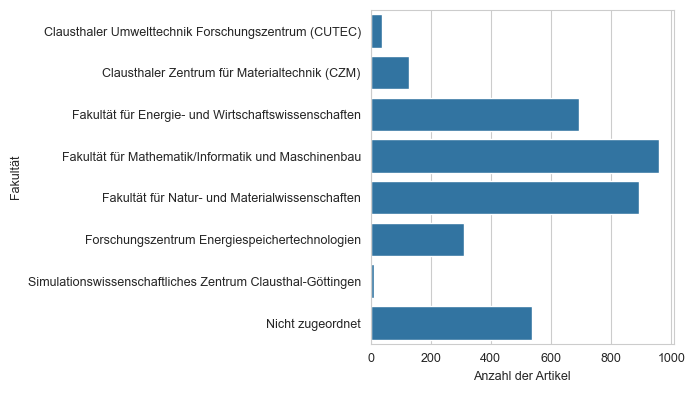

In [135]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [136]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8495798319327731

In [137]:
MAPPING_DICT_DEPT = {
    'Fakultät für Energie- und Wirtschaftswissenschaften': {
        'Institut für Aufbereitung, Deponietechnik und Geomechanik (IFAD)': ['deponietechnik', 'disposal research'],
        'Institut für Aufbereitung, Recycling und Kreislaufwirtschaftssysteme': ['waste processing', 'kreislaufwirtschaftssysteme', 'circular economy',
                                                                                 'socio-technical'
                                                                                ],
        'Institut für Bergbau': ['(surface|international) mining', 'institute of mining', 'mining engineering'],
        #'Institut für deutsches und internationales Berg- und Energierecht': [],
        'Institut für Elektrische Energietechnik und Energiesysteme': ['elektrische energietechnik', 'electrical(\spower)? engineering'],
        'Institut für Endlagerforschung': ['mineral resources', 'chair for geomechanics', 'endlagerforschung', 'hydrogeolog(ie|y)'],
        'Institut für Energieverfahrenstechnik und Brennstofftechnik': ['fuel technology', 'verfahrenstechnik', 'thermodynamics'],
        'Institut für Erdöl- und Erdgastechnik': ['petroleum engineering'],
        'Institut für Geologie und Paläontologie': ['paläontologie', 'pal(a)?eontology'],
        'Institut für Geophysik': ['institute of geophysics', 'institut f(ü|u)r geophysik'],
        'Institut für Wirtschaftswissenschaft': ['(behavioral|environmental) (economics|management)', 'management and economics', 
                                                 '(department|institute) of economics', 
                                                 'marketing', 'betriebswirtschaftslehre',
                                                 'digital transformation', 'market research', 'energy and economics'
                                                ],
        'Institute of Geotechnology and Mineral Resources': ['repository (research|systems)', 'geo-engineering', 'geotechnical engineering'],
        'Institute of Subsurface Energy Systems': ['surface energy']
    },
    'Fakultät für Mathematik/Informatik und Maschinenbau': {
        'Institut für Chemische und Elektrochemische Verfahrenstechnik': ['chemical', 'elektrochemisch'],
        'Institut für Elektrische Informationstechnik': ['electrical information technology', 'elektrische informationstechnik', 'metrology', '(mess|regelungs)technik'],
        'Institut für Informatik': ['(dep(t.|artment)|institute) (of|for) informatics', 'ins(t)?itut \S+ informatik', 'computer science', 'energy informatics'
                                   ],
        'Institut für Maschinelle Anlagentechnik und Betriebsfestigkeit': ['plant engineering', 'maschinelle anlagentechnik'],
        'Institut für Maschinenwesen': ['maschinenwesen', 'mechanical engineering'],
        'Institut für Mathematik': ['(dep(t.|artment)|institute) (of|for) mathematics', 'ins(t)?itut f(ü|u)?r mathematik', 'angewandte (stochastik|statistik)', 
                                    'applied (stochastics|statistics)', 'mathematical institute', 'continuous optimization'
                                   ],
        'Institut für Mechanische Verfahrenstechnik': ['particle technology'],
        'Institut für Prozeß- und Produktionsleittechnik': ['process technology', 'mechanical process'],
        'Institut für Schweißtechnik und Trennende Fertigungsverfahren': ['welding and (machining|cutting)', 'schweißtechnik', 'isaf,'],
        'Institut für Software and Systems Engineering': ['system(s)? engineering', 'human(-|\s)?centered information systems', 'isse,', 'software and systems'],
        'Institut für Technische Mechanik': ['applied mechanics', 'technical mechanics'],
        'Institut für Thermische Verfahrens- und Prozesstechnik': ['thermische verfahren'],
        'Institut für Tribologie und Energiewandlungsmaschinen': ['tribolog(ie|y)'],
    },
    'Fakultät für Natur- und Materialwissenschaften': {
        'Institut für Anorganische und Analytische Chemie': ['analytic(al)? chemistry', 'analytische chemie'],
        'Institut für Elektrochemie': ['electrochemistry', 'elektrochemie', 'forschungsbrauerei'],
        'Institut für Energieforschung und Physikalische Technologien': ['energy research', 'physikalische technologien'],
        'Institut für Metallurgie': ['metallurgy', 'metallurgie'],
        'Institut für Nichtmetallische Werkstoffe': ['non(-|‐)?metallic', 'nichtmetallische'],
        'Institut für Organische Chemie': ['organic(\s\S+)? chemistry', 'institut für organische chemie'],
        'Institut für Physikalische Chemie': ['physical chemistry', 'physikalische chemie'],
        'Institut für Polymerwerkstoffe und Kunststofftechnik': ['polymer materials', 'polymerwerkstoffe'],
        'Institut für Technische Chemie': ['technical chemistry', 'technische chemie'],
        'Institut für Theoretische Physik': ['theoretical physics', 'theoretische physik'],
        'Institut für Werkstoffkunde und Werkstofftechnik': ['(?<!natural and\s)materials science', 'werkstoff(technik|kunde)', 'materials engineering'],
    }
}

In [138]:
with open('./mapping_tables_dept/clausthal.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [139]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [140]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät für Natur- und Materialwissenschaften')

In [141]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Institute of Chemistry, University of Technology Clausthal, Leibnizstraße 4a, 38678, Clausthal-Zellerfeld, Germany',
       'Faculty of Natural and Materials Science, Clausthal University of Technology, Clausthal-Zellerfeld, Germany',
       'Faculty of Natural and Materials Science Clausthal University of Technology  Clausthal‐Zellerfeld Germany',
       'Faculty of Natural and Materials Science, Clausthal University of Technology, Robert-Koch-Strasse 42, 38678 Clausthal-Zellerfeld, Germany',
       'Faculty of Natural and Materials Science, Clausthal University of Technology, Robert-Koch-Straße 42, 38678, Clausthal-Zellerfeld, Germany',
       'Faculty of Natural and Materials Science, Clausthal University of Technology, Robert-Koch-Straße 42, 38678 Clausthal-Zellerfeld, Germany',
       'Faculty of Natural and Materials Science , Clausthal University of Technology , Agricolastraße 6 , Clausthal-Zellerfeld , , Germany'],
      dtype=object)

In [142]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Anorganische und Analytische Chemie,53
1,Institut für Elektrochemie,60
2,Institut für Energieforschung und Physikalisch...,105
3,Institut für Metallurgie,187
4,Institut für Nichtmetallische Werkstoffe,104
5,Institut für Organische Chemie,118
6,Institut für Physikalische Chemie,54
7,Institut für Polymerwerkstoffe und Kunststofft...,80
8,Institut für Technische Chemie,58
9,Institut für Theoretische Physik,12


In [143]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
1,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institute of Polymer Materials and Plastics En...,https://openalex.org/W4206450853,Institut für Polymerwerkstoffe und Kunststofft...
7,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Metallurgy, Clausthal University ...",https://openalex.org/W4293763474,Institut für Metallurgie
12,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Metallurgy, Clausthal University ...",https://openalex.org/W4293104651,Institut für Metallurgie
14,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-metallic Materials, Clausthal...",https://openalex.org/W4309343399,Institut für Nichtmetallische Werkstoffe
18,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W4312111002,Institut für Nichtmetallische Werkstoffe
...,...,...,...,...,...
3526,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3046910561,Institut für Nichtmetallische Werkstoffe
3527,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W2999671282,Institut für Nichtmetallische Werkstoffe
3528,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W4249050768,Institut für Nichtmetallische Werkstoffe
3529,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3175507923,Institut für Nichtmetallische Werkstoffe


In [144]:
MAPPING_DICT_INST = {}

In [145]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Technische Universität Clausthal'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/clausthal.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)